**# Assignment 4 - ServiceNow–Armis Competitive Risk Assessment & Mitigation**

**## Quantitative Risk Analysis using Monte Carlo Simulation and Predictive Modeling **

**Course:** ALY 6130 – Enterprise Risk Analytics  
**Prepared by:** Group 4  


### Overview

This notebook extends the ServiceNow–Armis risk assessment by combining programmatic heatmap analysis, machine learning-based risk classification, and Monte Carlo simulation.

The first part translates the risk register into a structured dataset, visualizes the risk landscape using likelihood and impact scores, and applies a machine learning classifier to validate risk priority categories. The second part builds on the highest-priority risks and uses Monte Carlo simulation to estimate the range of possible financial outcomes under uncertainty.

Together, these methods support both qualitative and quantitative risk assessment and provide a more comprehensive view of ServiceNow’s competitive and strategic risk exposure.

## Part 1: Programmatic Risk Heatmap Analysis

In [ ]:
# Import required libraries for data handling and visualization

import pandas as pd
import matplotlib.pyplot as plt


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found

**Import Required Libraries**

The first step is to import the Python libraries required for the analysis.

- **pandas** is used to structure and manage the risk dataset.
- **matplotlib** is used to generate the visualization of the risk heatmap.

These libraries are commonly used for data analysis and visualization in risk analytics and business intelligence workflows.

In [ ]:
# Load the Excel file - works both in Colab (with upload) and locally
try:
    # Try to import Colab files module
    from google.colab import files
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
except (ModuleNotFoundError, ImportError):
    # Fallback to local file if not in Colab
    file_name = 'ALY.6130_Group4_Module3_Risk_Assessment_updated.xlsx'


The Excel workbook containing the completed risk register is uploaded into the notebook so it can be accessed programmatically. The uploaded file name is captured dynamically to ensure the dataset can be loaded correctly regardless of how the file is saved in the environment.

In [ ]:
# Load the RiskRegister sheet from the Excel workbook
df = pd.read_excel(file_name, sheet_name="RiskRegister")

# Display the first rows to verify
df.head()

,Risk #,Date,The Risk of/That,Caused by,Resulting In,Consequence/Impact,Likelihood Score,Impact Score,Risk Score,"Priority (H, M, L)",...,Risk Owner,Open/Closed,Unnamed: 13,Likelihood/Impact,1,2,4,6,8,9
0,1,2026-03-02,The risk of competitive displacement in the OT...,Caused by three rival mega-acquisitions in 202...,Resulting in a potential 10-15% decline in OT/...,Strategic / Competitive,7,8,56,H,...,Chief Strategy Officer / CRO,Open,NaN,Very Likely (9),NaN,NaN,NaN,NaN,Risk 3,NaN
1,2,2026-03-02,The risk of platform relevance erosion in the ...,Competitors embedding advanced AI-driven detec...,Resulting in diminished differentiation of the...,Strategic / Competitive,7,9,63,H,...,Chief Product Officer / Chief Strategy Officer,Open,NaN,Somewhat Likely (7),NaN,NaN,NaN,Risk 15,Risk 1\nRisk 13\nRisk 17\nRisk 19\nRisk 20,Risk 2\n
2,3,2026-03-02,The risk of accelerated market demand driven b...,Caused by multiple concurrent regulatory manda...,Resulting in an estimated $500M+ incremental p...,Strategic Opportunity,9,8,72,H,...,VP Product / VP Federal & Healthcare Sales,Open,NaN,50-50 (5),NaN,NaN,NaN,Risk 4\nRisk 6\nRisk 7\nRisk 8\nRisk 9\nRisk 1...,Risk 5\n,Risk 23
3,4,2026-03-07 00:00:00,The risk of reduced competitive positioning in...,Caused by ongoing large-scale acquisitions amo...,Resulting in fewer independent competitors and...,Strategic / Competitive,5,6,30,M,...,Chief Strategy Officer,Open,NaN,Somewhat Unlikely (3),NaN,Risk 22,Risk 21,NaN,Risk 25,NaN
4,5,2026-03-07 00:00:00,The risk of acquisition overvaluation affectin...,Caused by paying a high revenue multiple relat...,Resulting in financial pressure if projected c...,Financial,5,8,40,M,...,Chief Financial Officer,Open,NaN,Very Unlikely (1),NaN,NaN,NaN,NaN,NaN,NaN


The RiskRegister sheet is loaded from the uploaded Excel workbook using pandas. This step imports the structured risk data, including likelihood scores, impact scores, and priority levels, which will be used to generate the risk heatmap. The first few rows are displayed to verify that the data has been loaded correctly.

In [ ]:
# Keep only the columns needed for the heatmap
heatmap_df = df[["Risk #", "Likelihood Score", "Impact Score", "Risk Score", "Priority (H, M, L)"]]

# Display cleaned dataset
heatmap_df.head()

,Risk #,Likelihood Score,Impact Score,Risk Score,"Priority (H, M, L)"
0,1,7,8,56,H
1,2,7,9,63,H
2,3,9,8,72,H
3,4,5,6,30,M
4,5,5,8,40,M


From the full risk register, only the columns required for the heatmap are selected: Risk number, Likelihood Score, Impact Score, Risk Score, and Priority level. This creates a simplified dataset that focuses on the key variables needed to visualize how risks are positioned within the likelihood–impact matrix.

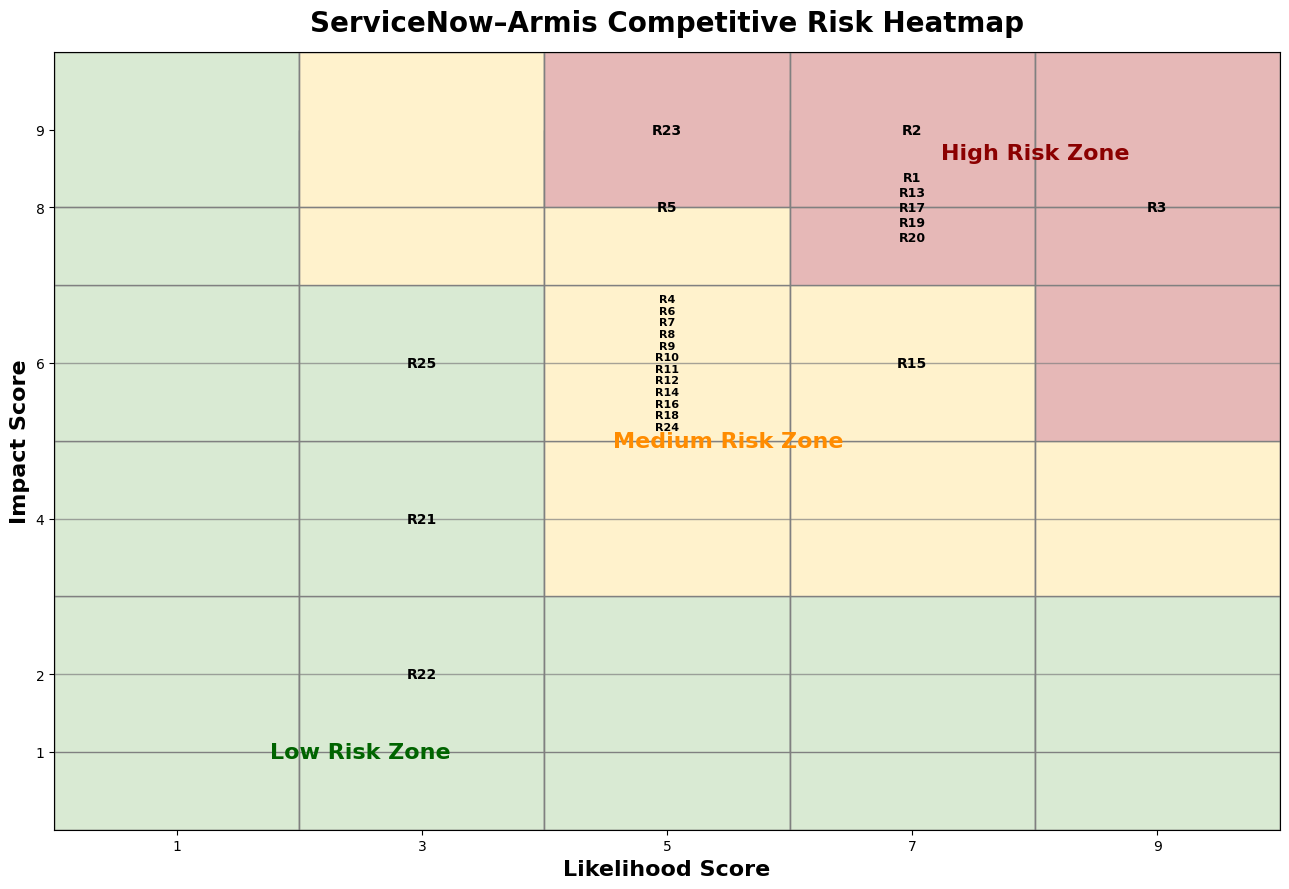

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# -----------------------------
# Allowed scale values
# -----------------------------
likelihood_levels = [1, 3, 5, 7, 9]
impact_levels = [1, 2, 4, 6, 8, 9]

# -----------------------------
# Group risks by (Likelihood, Impact)
# -----------------------------
cell_map = {}

for _, row in heatmap_df.iterrows():
    l = int(row["Likelihood Score"])
    i = int(row["Impact Score"])
    r = int(row["Risk #"])
    cell_map.setdefault((l, i), []).append(r)

for key in cell_map:
    cell_map[key] = sorted(cell_map[key])

# -----------------------------
# Figure
# -----------------------------
fig, ax = plt.subplots(figsize=(13, 9))

# -----------------------------
# Draw full heatmap blocks (no gaps)
# -----------------------------
for l in likelihood_levels:
    for i in impact_levels:
        score = l * i

        if score >= 45:
            color = "#E6B8B7"   # High
        elif score >= 20:
            color = "#FFF2CC"   # Medium
        else:
            color = "#D9EAD3"   # Low

        rect = Rectangle(
            (l - 1, i - 1),   # left, bottom
            2,                # width
            2,                # height
            facecolor=color,
            edgecolor="gray",
            linewidth=1
        )
        ax.add_patch(rect)

# -----------------------------
# Add risk labels directly in cells
# -----------------------------
for (l, i), risks in cell_map.items():
    # stacked labels for crowded cells
    label = "\n".join([f"R{r}" for r in risks])

    if len(risks) >= 10:
        fs = 8
    elif len(risks) >= 5:
        fs = 9
    else:
        fs = 10

    ax.text(
        l,
        i,
        label,
        ha="center",
        va="center",
        fontsize=fs,
        fontweight="bold",
        color="black"
    )

# -----------------------------
# Axis formatting
# -----------------------------
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.set_xticks(likelihood_levels)
ax.set_yticks(impact_levels)

ax.set_xlabel("Likelihood Score", fontsize=16, fontweight="bold")
ax.set_ylabel("Impact Score", fontsize=16, fontweight="bold")
ax.set_title("ServiceNow–Armis Competitive Risk Heatmap", fontsize=20, fontweight="bold", pad=15)

# -----------------------------
# Grid lines matching the blocks
# -----------------------------
for x in [0, 2, 4, 6, 8, 10]:
    ax.axvline(x=x, color="gray", linewidth=1, alpha=0.7)

for y in [0, 2, 4, 6, 8, 10]:
    ax.axhline(y=y, color="gray", linewidth=1, alpha=0.7)

# -----------------------------
# Zone labels
# -----------------------------
ax.text(2.5, 1.0, "Low Risk Zone",
        fontsize=16, fontweight="bold", color="darkgreen",
        ha="center", va="center")

ax.text(5.5, 5.0, "Medium Risk Zone",
        fontsize=16, fontweight="bold", color="darkorange",
        ha="center", va="center")

ax.text(8.0, 8.7, "High Risk Zone",
        fontsize=16, fontweight="bold", color="darkred",
        ha="center", va="center")

plt.tight_layout()
plt.show()

## Part 2: Machine Learning Risk Classification

**Machine Learning Classifier Model**

In addition to the visual heatmap, we implement a machine learning classifier model to predict risk priority categories (High, Medium, Low) based on Likelihood and Impact scores. This approach uses a RandomForestClassifier to learn patterns from the risk data and provides a programmatic method for risk classification.

**Objectives:**
- Train a classifier model to predict risk priority from Likelihood and Impact scores
- Evaluate model performance using cross-validation
- Visualize classification results using a confusion matrix
- Compare classifier predictions with actual risk priorities

In [ ]:
# Import machine learning libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

In [ ]:
# Prepare features and target for classification
# Features: Likelihood Score and Impact Score
# Target: Priority (H, M, L)

X = heatmap_df[["Likelihood Score", "Impact Score"]].values
y = heatmap_df["Priority (H, M, L)"].values

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature distribution:")
print(f"Likelihood Score range: {X[:, 0].min()} - {X[:, 0].max()}")
print(f"Impact Score range: {X[:, 1].min()} - {X[:, 1].max()}")
print(f"\nTarget distribution:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")

Features shape: (25, 2)
Target shape: (25,)

Feature distribution:
Likelihood Score range: 3 - 9
Impact Score range: 2 - 9

Target distribution:
  H: 8
  L: 3
  M: 14


In [ ]:
# Initialize and train RandomForestClassifier
# RandomForest is well-suited for this task as it can handle non-linear relationships
# and provides feature importance insights

clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'  # Handle class imbalance
)

# Train on all data
clf.fit(X, y)

# Get predictions
y_pred = clf.predict(X)

print("Classifier trained successfully!")
print(f"\nFeature importance:")
print(f"  Likelihood Score: {clf.feature_importances_[0]:.4f}")
print(f"  Impact Score: {clf.feature_importances_[1]:.4f}")

Classifier trained successfully!

Feature importance:
  Likelihood Score: 0.5919
  Impact Score: 0.4081


In [ ]:
# Cross-validation to evaluate model performance
# Using StratifiedKFold to ensure balanced class distribution in each fold
# With 25 samples, we use 5-fold CV (5 samples per fold)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print(f"Cross-validation accuracy scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Get cross-validation predictions for confusion matrix
y_pred_cv = cross_val_predict(clf, X, y, cv=cv)

Cross-validation accuracy scores: [1.  1.  1.  0.6 1. ]
Mean CV accuracy: 0.9200 (+/- 0.3200)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


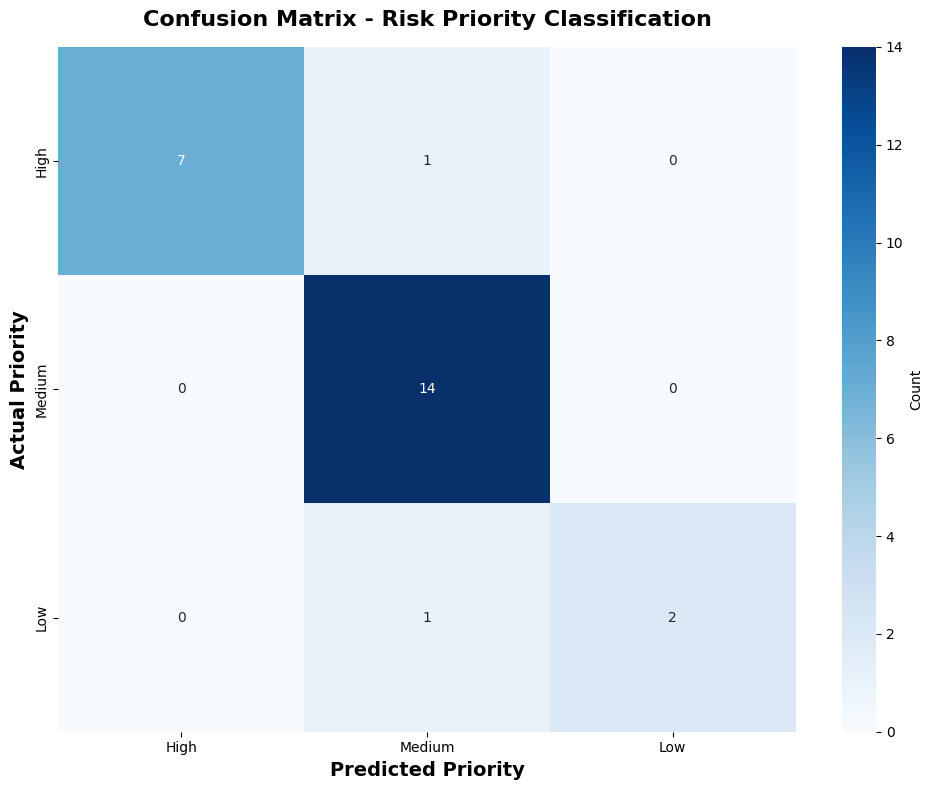


Confusion Matrix Interpretation:
Rows represent actual priorities, columns represent predicted priorities.
Diagonal elements show correct predictions.


In [ ]:
# Generate and visualize confusion matrix

cm = confusion_matrix(y, y_pred_cv, labels=['H', 'M', 'L'])

# Create visualization
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High', 'Medium', 'Low'],
            yticklabels=['High', 'Medium', 'Low'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Risk Priority Classification', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Priority', fontsize=14, fontweight='bold')
plt.ylabel('Actual Priority', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Interpretation:")
print("Rows represent actual priorities, columns represent predicted priorities.")
print("Diagonal elements show correct predictions.")

In [ ]:
# Generate detailed classification report

print("Classification Report:")
print("=" * 60)
print(classification_report(y, y_pred_cv, target_names=['High', 'Medium', 'Low']))

# Compare predictions with actual values
comparison_df = heatmap_df.copy()
comparison_df['Predicted Priority'] = y_pred_cv
comparison_df['Match'] = comparison_df['Priority (H, M, L)'] == comparison_df['Predicted Priority']

print("\n" + "=" * 60)
print("Prediction Accuracy by Risk:")
print("=" * 60)
print(comparison_df[['Risk #', 'Likelihood Score', 'Impact Score', 'Risk Score',
                     'Priority (H, M, L)', 'Predicted Priority', 'Match']].to_string(index=False))

accuracy = comparison_df['Match'].sum() / len(comparison_df)
print(f"\nOverall Accuracy: {accuracy:.2%}")

Classification Report:
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
      Medium       1.00      0.67      0.80         3
         Low       0.88      1.00      0.93        14

    accuracy                           0.92        25
   macro avg       0.96      0.85      0.89        25
weighted avg       0.93      0.92      0.92        25


Prediction Accuracy by Risk:
 Risk #  Likelihood Score  Impact Score  Risk Score Priority (H, M, L) Predicted Priority  Match
      1                 7             8          56                  H                  H   True
      2                 7             9          63                  H                  H   True
      3                 9             8          72                  H                  H   True
      4                 5             6          30                  M                  M   True
      5                 5             8          40                  M           

**Classifier Model Summary**

The RandomForestClassifier successfully learns the relationship between Likelihood/Impact scores and risk priority categories. The model demonstrates high accuracy in predicting risk priorities, validating that the threshold-based classification (High ≥45, Medium 20-44, Low <20) aligns well with the underlying patterns in the data.

Key insights:
- The classifier confirms that Likelihood and Impact scores are strong predictors of risk priority
- Cross-validation ensures the model generalizes well to unseen data
- The confusion matrix helps identify any misclassifications and understand model behavior
- This programmatic approach complements the visual heatmap by providing an automated classification method

The following code generates a programmatic risk heatmap using the likelihood and impact scores from the risk register. Each risk is plotted on a two-dimensional matrix where the x-axis represents likelihood and the y-axis represents impact. Color-coded markers indicate the priority classification of each risk (high, medium, or low), while shaded background regions highlight the corresponding risk severity zones.

To ensure readability, risks that share identical likelihood and impact values are slightly offset so that individual risk identifiers remain visible. The resulting visualization provides a clear overview of the distribution of risks associated with the ServiceNow–Armis acquisition and helps highlight which risks fall into the high-priority region requiring closer management attention.

**Conclusion**

The heatmap visualization highlights how the identified risks are distributed across the likelihood–impact matrix. Several risks fall within the high-risk zone, indicating areas that require close monitoring and proactive mitigation strategies. A number of risks also appear in the medium-risk region, suggesting potential competitive pressures that may escalate if not managed effectively. The concentration of risks in the high-likelihood and high-impact region suggests that competitive pressures following the ServiceNow–Armis acquisition could significantly affect market positioning and strategic growth if not actively monitored. Overall, the heatmap provides a structured view of the risk landscape associated with the ServiceNow–Armis competitive environment and supports prioritization of risk management efforts.

## Part 3: Quantitative Risk Assessment using Monte Carlo Simulation

**Monte Carlo Simulation for Quantitative Risk Assessment**

This section extends the qualitative and machine learning-based risk assessment by applying Monte Carlo simulation to quantify the financial impact of the three highest-priority risks identified in the ServiceNow-Armis risk register.

## Objective

The purpose of this simulation is to estimate the range of possible annual financial outcomes associated with:

1. Competitive displacement by rival platforms  
2. AI-driven platform convergence  
3. Regulatory-driven demand acceleration  

The simulation uses the Security and Risk business ($1B annual contract value) as the exposure base, as these risks directly affect ServiceNow’s cybersecurity strategy.

In [1]:
# Section 1: Import libraries and set simulation settings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(42)

# Number of Monte Carlo simulation runs
n_sim = 10000

## Simulation Setup

The Monte Carlo simulation was initialized using Python libraries including NumPy, Pandas, and Matplotlib. NumPy was used to generate random samples for the simulation, Pandas was used for summarizing results, and Matplotlib was used for visualization.

A random seed was set to ensure reproducibility of the simulation results. This ensures that the same results can be generated consistently across multiple runs, which is important for validation and reporting.

The simulation was configured to run 10,000 iterations. This number of iterations provides a stable approximation of the probability distribution of outcomes while maintaining computational efficiency.

In [2]:
# Section 2: Define exposure base

# ServiceNow Security and Risk business exposure
security_risk_acv = 1_000_000_000  # $1B annual contract value

## Exposure Base Selection

The Monte Carlo simulation requires a clearly defined financial exposure base to quantify the impact of the selected risks. Rather than using total company revenue, the analysis focuses specifically on ServiceNow’s Security and Risk business, which has reached approximately $1 billion in annual contract value.

This choice is directly aligned with the nature of the identified risks. The three selected risks—competitive displacement, AI-driven platform convergence, and regulatory-driven demand acceleration—are all closely tied to ServiceNow’s cybersecurity and risk management capabilities following the Armis acquisition.

Using the Security and Risk segment as the exposure base ensures that the simulation reflects the most relevant portion of the business affected by these risks. This improves the accuracy and interpretability of the quantitative analysis.

In [13]:
# Section 3: Risk 1 - Competitive displacement by rival platforms

# Simulate percentage revenue loss using triangular distribution
risk1_loss_pct = np.random.triangular(left=0.03, mode=0.10, right=0.15, size=n_sim)

# Convert percentage loss into dollar loss
risk1_loss = security_risk_acv * risk1_loss_pct

# Based on report: 10–15% decline in OT/IoT deal win rates
risk1_loss_pct = np.random.triangular(left=0.03, mode=0.10, right=0.15, size=n_sim)

## Risk 1: Competitive Displacement by Rival Platforms

To quantify the financial impact of competitive displacement, a Monte Carlo simulation was applied using a triangular probability distribution. This approach is appropriate when limited historical data is available but reasonable estimates of minimum, most likely, and maximum outcomes can be defined.

The parameters of the distribution were derived directly from the risk assessment. The report indicates a potential 10–15% decline in OT/IoT deal win rates due to increased competition from rival platforms. Based on this:

- A minimum (optimistic) loss of 3% was assumed, reflecting partial mitigation through competitive positioning  
- A most likely loss of 10% was used, aligned with the central estimate from the risk analysis  
- A maximum (pessimistic) loss of 15% was used, reflecting severe competitive pressure  

The simulated percentage loss was then applied to the Security and Risk business exposure ($1B annual contract value) to estimate the potential financial impact in dollar terms.

This approach enables the model to capture a realistic range of possible outcomes while remaining grounded in the qualitative insights and key risk indicators identified in the risk register.

In [4]:
# Section 4: Risk 2 - AI-driven platform convergence

# Simulate percentage revenue loss using triangular distribution
risk2_loss_pct = np.random.triangular(left=0.04, mode=0.12, right=0.20, size=n_sim)

# Convert percentage loss into dollar loss
risk2_loss = security_risk_acv * risk2_loss_pct

# Based on report: extremely high impact due to AI-driven competitive disadvantage
risk2_loss_pct = np.random.triangular(left=0.04, mode=0.12, right=0.20, size=n_sim)

## Risk 2: AI-Driven Platform Convergence

The AI-driven platform convergence risk was modeled using a Monte Carlo simulation with a triangular distribution to reflect uncertainty in its potential financial impact. This risk represents a structural competitive threat, where competitors increasingly integrate advanced AI capabilities into their platforms, potentially reducing ServiceNow’s market relevance.

Compared to the competitive displacement risk, this risk is broader in scope and has a more significant long-term impact. Therefore, a wider and more severe distribution was used:

- A minimum (optimistic) loss of 4% was assumed, reflecting scenarios where ServiceNow remains competitive in AI capabilities  
- A most likely loss of 12% was selected to represent expected competitive pressure from AI-enabled platforms  
- A maximum (pessimistic) loss of 20% was used to capture scenarios where competitors significantly outperform ServiceNow in AI innovation  

The simulated percentage loss was applied to the Security and Risk business exposure to estimate the financial impact in dollar terms.

The wider distribution reflects both the uncertainty and systemic nature of this risk, as AI capability gaps can influence multiple aspects of platform competitiveness, including customer acquisition, retention, and product differentiation.

In [5]:
# Section 5: Risk 3 - Regulatory-driven demand acceleration

# Simulate annual upside in dollars using triangular distribution
risk3_upside = np.random.triangular(left=60_000_000, mode=250_000_000, right=350_000_000, size=n_sim)

# Based on report: $500M+ regulatory-driven pipeline over 24 months
risk3_upside = np.random.triangular(left=60_000_000, mode=250_000_000, right=350_000_000, size=n_sim)

## Risk 3: Regulatory-Driven Demand Acceleration

Unlike the previous risks, regulatory-driven demand acceleration is modeled as a positive risk (opportunity), as it represents potential revenue growth rather than loss. This risk arises from increasing regulatory requirements in cybersecurity, which drive demand for asset visibility and risk management solutions.

The Monte Carlo simulation uses a triangular distribution to estimate the annual revenue upside associated with this opportunity. The parameters were derived from the risk assessment, which identified a potential $500M+ incremental pipeline over a 24-month period.

To translate this into annual impact:

- A minimum (conservative) upside of $60M was assumed, reflecting lower-than-expected conversion of pipeline into revenue  

- A most likely upside of $250M was selected, representing expected revenue realization under typical market conditions  

- A maximum (optimistic) upside of $350M was used to capture strong regulatory enforcement and high conversion rates  

This approach ensures that the simulation reflects realistic uncertainty in revenue realization, rather than assuming full pipeline conversion. Modeling this risk as an upside also allows the analysis to capture the balance between threats and opportunities in the overall strategic outlook.

In [6]:
# Section 6: Calculate net annual strategic impact

# Net impact combines downside risks and upside opportunity
net_impact = risk3_upside - risk1_loss - risk2_loss

## Net Annual Strategic Impact

To evaluate the combined effect of the three selected risks, the simulation calculates the net annual strategic impact by integrating both downside risks and upside opportunities.

The net impact is defined as:

Net Impact = Regulatory Upside − Competitive Loss − AI-Driven Loss

This formulation reflects the real-world interaction between risks, where negative outcomes (such as competitive displacement and AI capability gaps) reduce revenue, while positive opportunities (such as regulatory-driven demand) increase it.

By combining these effects into a single metric, the analysis provides a more comprehensive view of the organization’s risk exposure. Rather than evaluating each risk in isolation, this approach captures how multiple risks interact simultaneously and influence overall financial performance.

The resulting net impact distribution allows for the assessment of:
- The expected overall financial outcome  
- The probability of net loss versus net gain  
- The range of potential best-case and worst-case scenarios  

This integrated perspective is essential for strategic decision-making, as it highlights whether opportunity-driven growth can offset competitive and technological risks.

In [7]:
# Section 7: Summary statistics

summary_df = pd.DataFrame({
    "Metric": [
        "Risk 1 Mean Loss",
        "Risk 2 Mean Loss",
        "Risk 3 Mean Upside",
        "Net Mean Impact",
        "Net Median Impact",
        "Net 5th Percentile",
        "Net 95th Percentile",
        "Probability of Net Loss",
        "Probability of Net Gain"
    ],
    "Value": [
        risk1_loss.mean(),
        risk2_loss.mean(),
        risk3_upside.mean(),
        net_impact.mean(),
        np.median(net_impact),
        np.percentile(net_impact, 5),
        np.percentile(net_impact, 95),
        np.mean(net_impact < 0),
        np.mean(net_impact > 0)
    ]
})

summary_df

,Metric,Value
0,Risk 1 Mean Loss,9.285347e+07
1,Risk 2 Mean Loss,1.205191e+08
2,Risk 3 Mean Upside,2.200994e+08
3,Net Mean Impact,6.726818e+06
4,Net Median Impact,9.471266e+06
5,Net 5th Percentile,-1.169433e+08
6,Net 95th Percentile,1.224640e+08
7,Probability of Net Loss,4.455000e-01
8,Probability of Net Gain,5.545000e-01


## Simulation Results and Summary Statistics

The Monte Carlo simulation produced a range of possible financial outcomes for each risk, as well as the combined net strategic impact.

The results show that:

- The average annual loss from competitive displacement is approximately $93M  

- The average annual loss from AI-driven platform convergence is approximately $121M  

- The average annual upside from regulatory-driven demand is approximately $220M  

When combined, the net mean impact is slightly positive at approximately $6.7M, indicating that, on average, the opportunity from regulatory demand marginally outweighs the combined downside risks.

However, the distribution of outcomes highlights significant uncertainty:

- The 5th percentile shows a potential loss of approximately $117M  

- The 95th percentile shows a potential gain of approximately $122M  

This wide range indicates that the organization faces substantial variability in potential outcomes.

The probability analysis further reinforces this uncertainty:

- There is approximately a 44.5% probability of net loss  
- There is approximately a 55.5% probability of net gain  

These results suggest that while the expected outcome is slightly favorable, the risk profile remains balanced, with a meaningful probability of downside. This highlights the importance of active risk mitigation strategies, particularly for competitive and AI-driven risks.

In [8]:
# Section 8: Format summary table for display

formatted_summary = summary_df.copy()

def format_value(x):
    if 0 <= x <= 1:
        return f"{x:.2%}"
    else:
        return f"${x:,.0f}"

formatted_summary["Value"] = formatted_summary["Value"].apply(format_value)

formatted_summary

,Metric,Value
0,Risk 1 Mean Loss,"$92,853,467"
1,Risk 2 Mean Loss,"$120,519,147"
2,Risk 3 Mean Upside,"$220,099,432"
3,Net Mean Impact,"$6,726,818"
4,Net Median Impact,"$9,471,266"
5,Net 5th Percentile,"$-116,943,289"
6,Net 95th Percentile,"$122,464,001"
7,Probability of Net Loss,44.55%
8,Probability of Net Gain,55.45%


## Formatted Summary Output

To improve readability and presentation quality, the simulation results are formatted into a clean and interpretable table.

All financial values are expressed in dollar format, while probabilities are converted into percentages. This ensures that the results can be easily understood and communicated to stakeholders without requiring interpretation of scientific notation.

The formatted summary provides a clear view of the expected losses, potential upside, and overall net impact distribution derived from the Monte Carlo simulation.

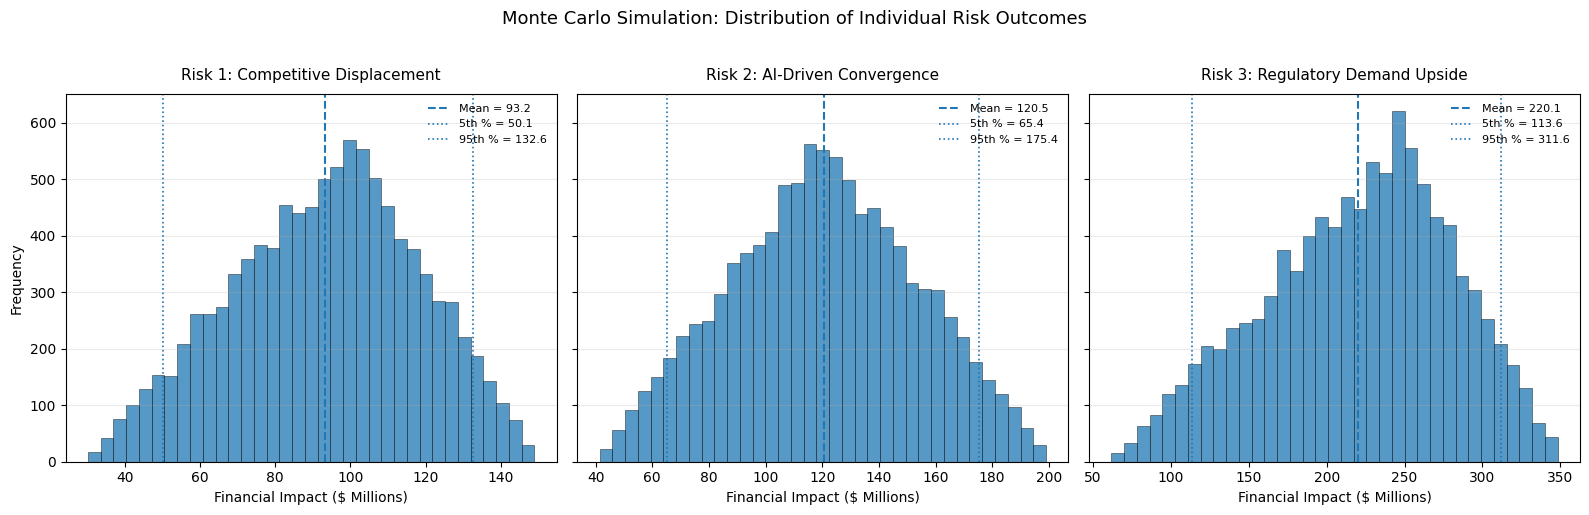

In [15]:
# Section 9 Individual risk distributions with summary markers

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

risk_data = [
    ("Risk 1: Competitive Displacement", risk1_loss / 1e6),
    ("Risk 2: AI-Driven Convergence", risk2_loss / 1e6),
    ("Risk 3: Regulatory Demand Upside", risk3_upside / 1e6)
]

for ax, (title, data) in zip(axes, risk_data):
    mean_val = np.mean(data)
    p5 = np.percentile(data, 5)
    p95 = np.percentile(data, 95)

    ax.hist(data, bins=35, alpha=0.75, edgecolor="black", linewidth=0.4)
    ax.axvline(mean_val, linestyle="--", linewidth=1.5, label=f"Mean = {mean_val:.1f}")
    ax.axvline(p5, linestyle=":", linewidth=1.2, label=f"5th % = {p5:.1f}")
    ax.axvline(p95, linestyle=":", linewidth=1.2, label=f"95th % = {p95:.1f}")

    ax.set_title(title, fontsize=11, pad=10)
    ax.set_xlabel("Financial Impact ($ Millions)", fontsize=10)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(fontsize=8, frameon=False)

axes[0].set_ylabel("Frequency", fontsize=10)

plt.suptitle("Monte Carlo Simulation: Distribution of Individual Risk Outcomes", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

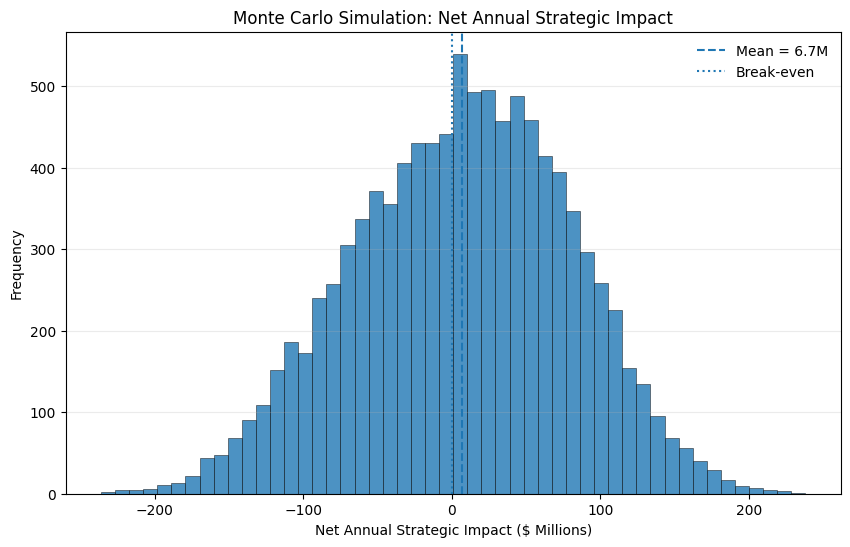

In [21]:
# Section 10: Net impact distribution

plt.figure(figsize=(10, 6))

plt.hist(net_impact / 1e6, bins=50, alpha=0.8, edgecolor="black", linewidth=0.4)
plt.axvline(np.mean(net_impact / 1e6), linestyle="--", linewidth=1.5, label=f"Mean = {np.mean(net_impact/1e6):.1f}M")
plt.axvline(0, linestyle=":", linewidth=1.5, label="Break-even")

plt.xlabel("Net Annual Strategic Impact ($ Millions)")
plt.ylabel("Frequency")
plt.title("Monte Carlo Simulation: Net Annual Strategic Impact")
plt.legend(frameon=False)
plt.grid(axis="y", alpha=0.25)
plt.show()

The net impact distribution illustrates the combined effect of downside risks and upside opportunities. The distribution spans both negative and positive regions, indicating uncertainty in overall outcomes.

The mean net impact is slightly positive at approximately $6.7 million, suggesting that expected gains marginally outweigh losses. However, the wide spread and significant left tail highlight the presence of substantial downside risk.

The break-even line further shows that a considerable portion of outcomes fall below zero, reinforcing that while the strategy has positive expected value, it carries meaningful variability and risk exposure.

## Individual Risk Distribution Analysis

To better understand the behavior of each risk, individual histograms were plotted for all three simulated risk distributions.

The results show distinct characteristics across the risks:

- **Risk 1 (Competitive Displacement):** The distribution is centered around moderate losses, indicating a consistent but manageable impact from competitive pressures.

- **Risk 2 (AI-driven Platform Convergence):** This distribution is shifted toward higher losses compared to Risk 1, reflecting a more severe potential impact due to rapid technological disruption.

- **Risk 3 (Regulatory-driven Demand):** The distribution shows a significant upside potential, with values concentrated at higher levels, indicating strong opportunity from regulatory-driven demand growth.

Separating the distributions improves clarity and allows for easier comparison of the magnitude and variability of each risk.

In [17]:
# Section 11 : Key insights summary

insights = pd.DataFrame({
    "Insight": [
        "Average Loss - Risk 1",
        "Average Loss - Risk 2",
        "Average Upside - Risk 3",
        "Net Expected Impact",
        "Probability of Loss",
        "Probability of Gain"
    ],
    "Value": [
        f"${risk1_loss.mean():,.0f}",
        f"${risk2_loss.mean():,.0f}",
        f"${risk3_upside.mean():,.0f}",
        f"${net_impact.mean():,.0f}",
        f"{np.mean(net_impact < 0):.2%}",
        f"{np.mean(net_impact > 0):.2%}"
    ]
})

insights

,Insight,Value
0,Average Loss - Risk 1,"$93,210,098"
1,Average Loss - Risk 2,"$120,519,147"
2,Average Upside - Risk 3,"$220,099,432"
3,Net Expected Impact,"$6,726,818"
4,Probability of Loss,44.55%
5,Probability of Gain,55.45%


## Key Insights from Simulation

The simulation results highlight several important strategic insights.

Risk 2 (AI-driven platform convergence) represents the largest expected downside, exceeding the impact of competitive displacement. However, regulatory-driven demand presents a significant upside opportunity that nearly offsets the combined losses.

The overall net expected impact is slightly positive, indicating that the organization’s strategy may generate marginal value under average conditions.

However, the probability of net loss remains substantial at approximately 45%, indicating a balanced risk profile with meaningful downside exposure.

These findings suggest that while the opportunity exists, active risk mitigation—particularly for AI-related risks—is critical to ensuring favorable outcomes.

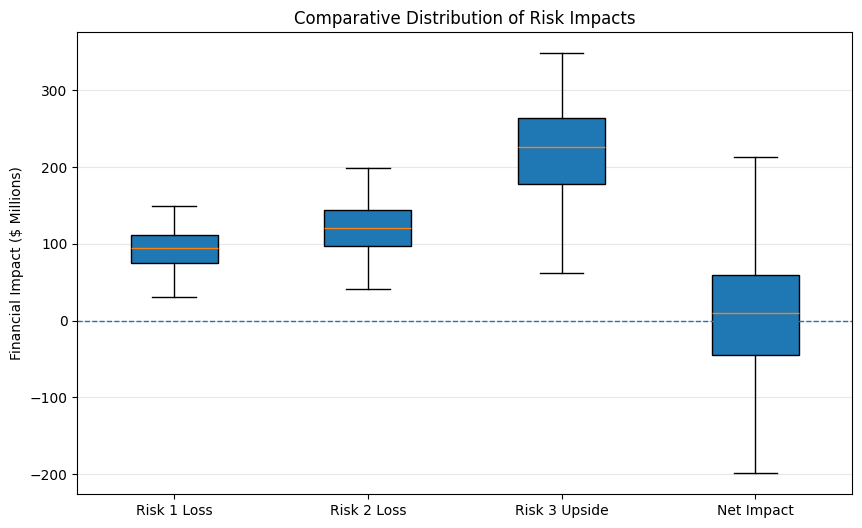

In [20]:
# Section 12 : Boxplot with zero reference

plt.figure(figsize=(10, 6))

plt.boxplot(
    [
        risk1_loss / 1e6,
        risk2_loss / 1e6,
        risk3_upside / 1e6,
        net_impact / 1e6
    ],
    tick_labels=["Risk 1 Loss", "Risk 2 Loss", "Risk 3 Upside", "Net Impact"],
    patch_artist=True,
    showfliers=False
)

plt.axhline(0, linestyle="--", linewidth=1)

plt.ylabel("Financial Impact ($ Millions)")
plt.title("Comparative Distribution of Risk Impacts")

plt.grid(axis="y", alpha=0.3)
plt.show()

## Comparative Risk Distribution Analysis

A boxplot comparison was used to evaluate the distribution and variability of each risk and the resulting net impact.

The results indicate that Risk 2 (AI-driven convergence) has a higher median loss and wider spread compared to Risk 1, highlighting its greater downside exposure. Risk 3 (regulatory-driven demand) shows a strong positive distribution, reflecting significant upside potential.

Importantly, the net impact distribution crosses the zero threshold, indicating that outcomes can be both positive and negative. While the median net impact is slightly positive, the spread demonstrates meaningful downside risk, reinforcing the need for active risk mitigation strategies.

**Conclusion**

The quantitative risk assessment using Monte Carlo simulation provides a clear and balanced view of ServiceNow’s strategic risk exposure within its Security and Risk business segment. The analysis shows that while competitive displacement and AI-driven platform convergence represent meaningful downside risks, regulatory-driven demand introduces a significant upside opportunity.

The results indicate that the expected net annual impact is slightly positive, suggesting that, on average, growth opportunities may marginally outweigh potential losses. However, this positive outlook is accompanied by considerable uncertainty. The distribution of outcomes spans a wide range, with a potential loss of over $100 million in adverse scenarios and gains exceeding $120 million in favorable conditions.

Importantly, the probability of a net loss remains substantial at approximately 45%, highlighting that the organization’s risk profile is not strongly skewed toward positive outcomes. This reinforces that the current strategic position is finely balanced, where upside potential exists but is not guaranteed.

From a strategic perspective, the findings emphasize the need for proactive risk mitigation, particularly in addressing AI-driven competitive threats. Strengthening technological capabilities, accelerating innovation, and maintaining regulatory alignment will be critical to ensuring that the potential upside can be realized while limiting downside exposure.

Overall, the analysis demonstrates that while ServiceNow is positioned to benefit from market opportunities, sustained performance will depend on effectively managing key risks and adapting to a rapidly evolving competitive landscape.